# Libraries

In [731]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [732]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240610 - Ag60 GDE_0.6M K2SO4_pH3

17-Aug-26  12:00 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:44 PM    <DIR>          .ipynb_checkpoints
30-Jul-26  11:09 AM            73,203 0p6M_pH3 K2SO4_20240611_0641_1min - Copy.xlsx
30-Jul-26  11:10 AM            47,648 0p6M_pH3 K2SO4_20240611_0641_1min.xlsx
11-Jun-24  08:42 AM            10,763 0p6M_pH3 K2SO4_20240611_0641_5min.xlsx
11-Jun-24  08:42 AM           236,076 0p6M_pH3 K2SO4_20240611_0641_Line_1.csv
12-May-25  02:01 PM           714,841 20240610 - Ag60 GDE_0.6 M K2SO4_pH3.ipynb
17-Aug-26  12:00 AM           818,439 20240610 - Ag60 GDE_0.6 M K2SO4_pH3-CORRECTED.ipynb
11-Aug-26  09:45 AM               584 20240610_0.6 M K2SO4_pH3_Energy Consumption.csv
16-Aug-26  10:48 PM             5,830 20240610_0.6M K2SO4_pH3.csv
11-Aug-26  09:43 AM             1,398 202

# Load Data

In [733]:
Book = "Book_20240610 - Ag60 GDE_0.6 M K2SO4_pH3.xlsx"
Book = pd.read_excel(Book)
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,43.278512,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-10 15:33:14.170,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
1,Ag60 GDE in PTFE holder,60,53.247892,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 16:11:35.000,0.639119,0.076311,...,0.000708,0.019224,0.967852,0.003970,0.039896,1.083874,NaN,1.123770,0.019476,NaN
2,Ag60 GDE in PTFE holder,60,57.490757,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 16:43:37.000,1.173008,0.110051,...,0.001020,0.018037,0.977048,0.001784,0.062076,1.097959,NaN,1.160035,0.018126,107.385901
3,Ag60 GDE in PTFE holder,60,58.253663,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 17:07:07.000,1.564675,0.119555,...,0.001110,0.017453,0.978711,0.001365,0.068435,1.076531,NaN,1.144966,0.017521,NaN
4,Ag60 GDE in PTFE holder,60,61.574866,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 17:42:08.000,2.148286,0.142407,...,0.001320,0.022553,0.973933,0.001252,0.039849,0.680740,NaN,0.720589,0.022633,107.486948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,Ag60 GDE in PTFE holder,60,62.952133,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.500,2024-06-11 07:42:50.000,16.159953,12.706196,...,0.122985,0.105118,0.764331,0.007547,2.049398,1.751656,NaN,3.801054,0.120902,89.826759
59,Ag60 GDE in PTFE holder,60,56.410178,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.500,2024-06-11 07:57:51.000,16.410231,8.090273,...,0.077662,0.095487,0.821895,0.004888,1.159661,1.425811,NaN,2.585472,0.104086,NaN
60,Ag60 GDE in PTFE holder,60,55.954992,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.500,2024-06-11 08:12:53.000,16.660786,1.312806,...,0.012190,0.014914,0.971950,0.000799,0.180556,0.220893,NaN,0.401449,0.015112,106.278748
61,Ag60 GDE in PTFE holder,60,57.143395,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.500,2024-06-11 08:27:54.000,16.911064,0.203536,...,0.001877,0.002191,0.995713,0.000129,0.028390,0.033135,NaN,0.061525,0.002195,NaN


In [734]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
60,Ag60 GDE in PTFE holder,60,55.95,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-11 08:12:53,16.66,1.312806,...,0.014914,0.971950,0.000799,0.180556,0.220893,NaN,0.401449,0.015112,106.278748,55.95
61,Ag60 GDE in PTFE holder,60,57.14,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-11 08:27:54,16.91,0.203536,...,0.002191,0.995713,0.000129,0.028390,0.033135,NaN,0.061525,0.002195,NaN,57.14
62,Ag60 GDE in PTFE holder,60,33.84,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.5,2024-06-11 08:42:55,17.16,0.006368,...,0.000541,0.999305,0.000031,0.000526,0.004843,NaN,0.005369,0.000541,108.372859,33.84


#### Temp from pH meter

In [735]:
Temp = "2024-06-11_084020.csv"
Temp = pd.read_csv(Temp, sep = ",")
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.96072796934866
Temp C median: 24.2


### Power Supply

In [736]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.00V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,10.06.2024 15:33:14.170
1,40.00V,2.50V,0.100A,0.116A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,10.06.2024 15:33:19.171


In [737]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.00V
0.100A 1    2.50V
       2    2.63V

In [738]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "median",
        "U actual": "median"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-06-10 14:00:00     0.116      3.05
1 2024-06-10 16:00:00     0.116      3.08
2 2024-06-10 18:00:00     0.266      3.51
3 2024-06-10 20:00:00     0.514      4.13
4 2024-06-10 22:00:00     0.765      4.74
5 2024-06-11 00:00:00     1.014      5.26
6 2024-06-11 02:00:00     1.509      6.21
7 2024-06-11 04:00:00     2.011      7.33
8 2024-06-11 06:00:00     3.005      8.68


In [739]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[1:].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-06-10 16:00:00     0.116      3.08
1 2024-06-10 18:00:00     0.266      3.51
2 2024-06-10 20:00:00     0.514      4.13
3 2024-06-10 22:00:00     0.765      4.74
4 2024-06-11 00:00:00     1.014      5.26
5 2024-06-11 02:00:00     1.509      6.21
6 2024-06-11 04:00:00     2.011      7.33
7 2024-06-11 06:00:00     3.005      8.68


In [740]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [741]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.116,3.08
0.266,3.51
0.514,4.13
0.765,4.74
1.014,5.26
1.509,6.21
2.011,7.33
3.005,8.68


In [742]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.116,3.08,1.16
0.266,3.51,2.66
0.514,4.13,5.14
0.765,4.74,7.65
1.014,5.26,10.14
1.509,6.21,15.09
2.011,7.33,20.11
3.005,8.68,30.05


## Flow rate

In [743]:
flow_rate = "0p6M_pH3 K2SO4_20240611_0641_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-11 06:41:52.598000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p6M_pH3 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [744]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-06-10 13:32:59.971000,43.278512,21.639256
1,2024-06-10 13:34:00.019000,46.154196,23.077098
2,2024-06-10 13:34:59.981000,44.331066,22.165533
3,2024-06-10 13:36:00.029000,45.513509,22.756755
4,2024-06-10 13:36:59.990000,44.63595,22.317975
...,...,...,...
1025,2024-06-11 06:38:00.010000,58.750851,29.375425
1026,2024-06-11 06:38:59.971000,58.55246,29.27623
1027,2024-06-11 06:40:00.019000,59.05886,29.52943
1028,2024-06-11 06:40:59.981000,59.066036,29.533018


In [745]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-10 12:00:00     43.278512     51.609336      47.325606   
1 2024-06-10 14:00:00     49.219328     62.108206      57.592174   
2 2024-06-10 16:00:00     60.165426     63.369918       61.65112   
3 2024-06-10 18:00:00     60.502984     64.573878      62.081064   
4 2024-06-10 20:00:00      60.93475     64.071888      62.460538   
5 2024-06-10 22:00:00     61.322032     67.202592      63.669749   
6 2024-06-11 00:00:00     64.356012     73.367319       66.51029   
7 2024-06-11 02:00:00     67.429572     80.395776      71.227716   
8 2024-06-11 04:00:00     55.158501     80.069256       74.63643   
9 2024-06-11 06:00:00      33.84257     59.066036      56.385183   

  Flow_rate_median  
0        47.394734  
1        58.421619  
2        61.712164  
3        62.070955  
4        62.416543  
5        63.101377  
6        65.783587  
7        69.204551  
8        77.926747  
9        56.685112  


#### Correction for dry flow

In [746]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.398 L/mol
p_sat = 3.0205 kPa -> x(H2O) = 2.98 % -> dry factor 0.97019


In [747]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [748]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-10 12:00:00     43.278512     51.609336      47.325606   
1 2024-06-10 14:00:00     49.219328     62.108206      57.592174   
2 2024-06-10 16:00:00     60.165426     63.369918       61.65112   
3 2024-06-10 18:00:00     60.502984     64.573878      62.081064   
4 2024-06-10 20:00:00      60.93475     64.071888      62.460538   
5 2024-06-10 22:00:00     61.322032     67.202592      63.669749   
6 2024-06-11 00:00:00     64.356012     73.367319       66.51029   
7 2024-06-11 02:00:00     67.429572     80.395776      71.227716   
8 2024-06-11 04:00:00     55.158501     80.069256       74.63643   
9 2024-06-11 06:00:00      33.84257     59.066036      56.385183   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0        47.394734         41.988366         50.070845          45.914814   
1        58.421619         47.752084         60.256741          55.875333   
2        61.712164  

In [749]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-2].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-06-10 12:00:00,43.278512,51.609336,47.325606,47.394734,41.988366,50.070845,45.914814,45.981882,0.116,3.08
1,2024-06-10 14:00:00,49.219328,62.108206,57.592174,58.421619,47.752084,60.256741,55.875333,56.680052,0.266,3.51
2,2024-06-10 16:00:00,60.165426,63.369918,61.65112,61.712164,58.371875,61.48084,59.813281,59.872504,0.514,4.13
3,2024-06-10 18:00:00,60.502984,64.573878,62.081064,62.070955,58.699371,62.64891,60.230408,60.2206,0.765,4.74
4,2024-06-10 20:00:00,60.93475,64.071888,62.460538,62.416543,59.118266,62.161885,60.598569,60.555886,1.014,5.26
5,2024-06-10 22:00:00,61.322032,67.202592,63.669749,63.101377,59.494003,65.199261,61.771734,61.220305,1.509,6.21
6,2024-06-11 00:00:00,64.356012,73.367319,66.51029,65.783587,62.437539,71.180216,64.527597,63.822557,2.011,7.33
7,2024-06-11 02:00:00,67.429572,80.395776,71.227716,69.204551,65.419475,77.999152,69.104395,67.141541,3.005,8.68


In [752]:
# dfflow_rate.to_csv('20240610_0.6M K2SO4_pH3_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [753]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.116,3.08,1.16,116.0
0.266,3.51,2.66,266.0
0.514,4.13,5.14,514.0


In [754]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.116,3.08,1.16,116.0,2572.416
0.266,3.51,2.66,266.0,6722.352
0.514,4.13,5.14,514.0,15284.304
0.765,4.74,7.65,765.0,26107.920
1.014,5.26,10.14,1014.0,38402.208
1.509,6.21,15.09,1509.0,67470.408
2.011,7.33,20.11,2011.0,106132.536
3.005,8.68,30.05,3005.0,187800.480


In [755]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.116,3.08,1.16,116.0,2572.416,0.000715
0.266,3.51,2.66,266.0,6722.352,0.001867
0.514,4.13,5.14,514.0,15284.304,0.004246
0.765,4.74,7.65,765.0,26107.920,0.007252
1.014,5.26,10.14,1014.0,38402.208,0.010667
1.509,6.21,15.09,1509.0,67470.408,0.018742
2.011,7.33,20.11,2011.0,106132.536,0.029481
3.005,8.68,30.05,3005.0,187800.480,0.052167


In [758]:
# dfcell_voltage.to_csv('20240610_0.6 M K2SO4_pH3_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [759]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,43.28,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-10 15:33:14.170,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,43.28,0.0
1,Ag60 GDE in PTFE holder,60,53.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 16:11:35.000,0.64,0.076311,...,0.967852,0.003970,0.039896,1.083874,NaN,1.123770,0.019476,NaN,53.25,0.0
2,Ag60 GDE in PTFE holder,60,57.49,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 16:43:37.000,1.17,0.110051,...,0.977048,0.001784,0.062076,1.097959,NaN,1.160035,0.018126,107.385901,57.49,1.0
3,Ag60 GDE in PTFE holder,60,58.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 17:07:07.000,1.56,0.119555,...,0.978711,0.001365,0.068435,1.076531,NaN,1.144966,0.017521,NaN,58.25,1.0
4,Ag60 GDE in PTFE holder,60,61.57,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 17:42:08.000,2.15,0.142407,...,0.973933,0.001252,0.039849,0.680740,NaN,0.720589,0.022633,107.486948,61.57,2.0
5,Ag60 GDE in PTFE holder,60,61.98,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 18:17:10.000,2.73,0.243144,...,0.964873,0.001197,0.068847,0.937643,NaN,1.006490,0.030993,NaN,61.98,2.0
6,Ag60 GDE in PTFE holder,60,62.72,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 18:42:10.000,3.15,0.232823,...,0.965454,0.001043,0.066954,0.952062,NaN,1.019016,0.031077,106.531408,62.72,3.0
7,Ag60 GDE in PTFE holder,60,61.80,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 18:57:09.000,3.40,0.236201,...,0.965855,0.000971,0.066982,0.933974,NaN,1.000956,0.030932,NaN,61.80,3.0
8,Ag60 GDE in PTFE holder,60,60.85,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 19:12:10.000,3.65,0.240052,...,0.965763,0.000982,0.066972,0.919703,NaN,0.986675,0.030937,106.556898,60.85,3.0
9,Ag60 GDE in PTFE holder,60,62.50,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 19:27:11.000,3.90,0.244044,...,0.965858,0.000973,0.069998,0.941107,NaN,1.011105,0.030822,NaN,62.50,3.0


## Current Density

In [760]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book.head(15)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,43.28,0.3 M K2SO4,Deionized wated,CCM-CEM,0.000,2024-06-10 15:33:14.170,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,43.28,0.0,0.0
1,Ag60 GDE in PTFE holder,60,53.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 16:11:35.000,0.64,0.076311,...,0.003970,0.039896,1.083874,NaN,1.123770,0.019476,NaN,53.25,0.0,-125.0
2,Ag60 GDE in PTFE holder,60,57.49,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 16:43:37.000,1.17,0.110051,...,0.001784,0.062076,1.097959,NaN,1.160035,0.018126,107.385901,57.49,1.0,-125.0
3,Ag60 GDE in PTFE holder,60,58.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.125,2024-06-10 17:07:07.000,1.56,0.119555,...,0.001365,0.068435,1.076531,NaN,1.144966,0.017521,NaN,58.25,1.0,-125.0
4,Ag60 GDE in PTFE holder,60,61.57,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 17:42:08.000,2.15,0.142407,...,0.001252,0.039849,0.680740,NaN,0.720589,0.022633,107.486948,61.57,2.0,-270.0
5,Ag60 GDE in PTFE holder,60,61.98,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 18:17:10.000,2.73,0.243144,...,0.001197,0.068847,0.937643,NaN,1.006490,0.030993,NaN,61.98,2.0,-270.0
6,Ag60 GDE in PTFE holder,60,62.72,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 18:42:10.000,3.15,0.232823,...,0.001043,0.066954,0.952062,NaN,1.019016,0.031077,106.531408,62.72,3.0,-270.0
7,Ag60 GDE in PTFE holder,60,61.80,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 18:57:09.000,3.40,0.236201,...,0.000971,0.066982,0.933974,NaN,1.000956,0.030932,NaN,61.80,3.0,-270.0
8,Ag60 GDE in PTFE holder,60,60.85,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 19:12:10.000,3.65,0.240052,...,0.000982,0.066972,0.919703,NaN,0.986675,0.030937,106.556898,60.85,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,62.50,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.270,2024-06-10 19:27:11.000,3.90,0.244044,...,0.000973,0.069998,0.941107,NaN,1.011105,0.030822,NaN,62.50,3.0,-270.0


## FE(CO)

In [761]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [762]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.398 L/mol


In [763]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.116, 0.266, 0.514, 0.765, 1.014, 1.509, 2.011, 3.005]

In [764]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[4, 6, 8, 8, 8, 8, 8, 8]

In [765]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.116                0.001  0.018
0.266                0.002  0.031
0.514                0.004  0.056
0.765                0.009  0.078
1.014                0.020  0.092
1.509                0.051  0.115
2.011                0.095  0.120
3.005                0.185  0.113


In [766]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 104.1 / 87.3 %


In [767]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,53.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.116,2024-06-10 16:11:35,0.64,0.076311,...,53.25,0.0,-116.0,0.125,0.116,45.914814,41.988366,50.070845,45.981882,104.149861


In [768]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.16].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,53.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.116,2024-06-10 16:11:35,0.64,0.076311,...,53.25,0.0,-116.0,0.125,0.116,45.914814,41.988366,50.070845,45.981882,104.149861
2,Ag60 GDE in PTFE holder,60,57.49,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.116,2024-06-10 16:43:37,1.17,0.110051,...,57.49,1.0,-116.0,0.125,0.116,45.914814,41.988366,50.070845,45.981882,99.576479
3,Ag60 GDE in PTFE holder,60,58.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.116,2024-06-10 17:07:07,1.56,0.119555,...,58.25,1.0,-116.0,0.125,0.116,45.914814,41.988366,50.070845,45.981882,96.995808
5,Ag60 GDE in PTFE holder,60,61.98,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 18:17:10,2.73,0.243144,...,61.98,2.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,93.048591
6,Ag60 GDE in PTFE holder,60,62.72,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 18:42:10,3.15,0.232823,...,62.72,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,93.093077
7,Ag60 GDE in PTFE holder,60,61.80,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 18:57:09,3.40,0.236201,...,61.80,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,92.804069
8,Ag60 GDE in PTFE holder,60,60.85,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 19:12:10,3.65,0.240052,...,60.85,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,92.907158
9,Ag60 GDE in PTFE holder,60,62.50,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 19:27:11,3.90,0.244044,...,62.50,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,92.694465
10,Ag60 GDE in PTFE holder,60,62.08,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.514,2024-06-10 21:27:15,5.90,0.464905,...,62.08,5.0,-514.0,0.520,0.514,59.813281,58.371875,61.48084,59.872504,93.178897
11,Ag60 GDE in PTFE holder,60,61.71,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.514,2024-06-10 21:12:14,5.65,0.429336,...,61.71,5.0,-514.0,0.520,0.514,59.813281,58.371875,61.48084,59.872504,92.872397


### Mean FE per current density

In [769]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        116    4.941186   95.299530      5.328575     94.247904   0.636412   
1        266    6.283038   86.626434      6.306209     86.600949   0.053938   
2        514    5.935362   86.324607      6.062558     86.659515   0.196613   
3        765    9.106897   80.754428      9.112651     80.883347   0.228719   
4       1014   15.828310   72.767804     15.873841     72.857071   0.153154   
5       1509   27.554674   61.433735     27.463043     61.725862   0.403113   
6       2011   38.954803   50.282561     39.870395     50.286544   1.133825   
7       3005   54.753858   33.087257     54.991719     33.152896   0.589992   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   2.722673   1.102298   4.715808   4.513031  ...   0.000946     0.001020  3   
1   0.111665   0.120610   0.249691   6.210302  ...   0.002237     0.002245  5   
2   0.297471   0.520190   0.787034   5.668644

## FE(H2)

In [770]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
print(rows["FE(H2)"])

1      3.697487
2      5.328575
3      5.797495
5      6.364830
6      6.116673
7      6.210302
8      6.306209
9      6.417174
10     6.728851
11     6.212882
12     6.077160
13     5.878208
14     5.459081
15     5.128795
17     6.062558
19     8.237005
20     8.621169
21     8.760571
22     9.112651
23     9.422232
24     9.671451
25     9.923200
26    15.974927
27    16.309121
28    16.211947
29    15.873841
30    15.497941
31    15.140867
33    15.789528
34    29.142726
36    25.881066
37    26.975061
38    27.150751
39    27.463043
40    27.734418
41    28.535652
42    41.571804
43    41.242618
44    40.820985
45    40.170725
46    38.876722
47    37.712083
48    31.673425
49    39.570066
50    54.991719
51    55.566278
52    54.222522
53    56.124826
54    52.176740
56    53.538022
57    56.656897
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

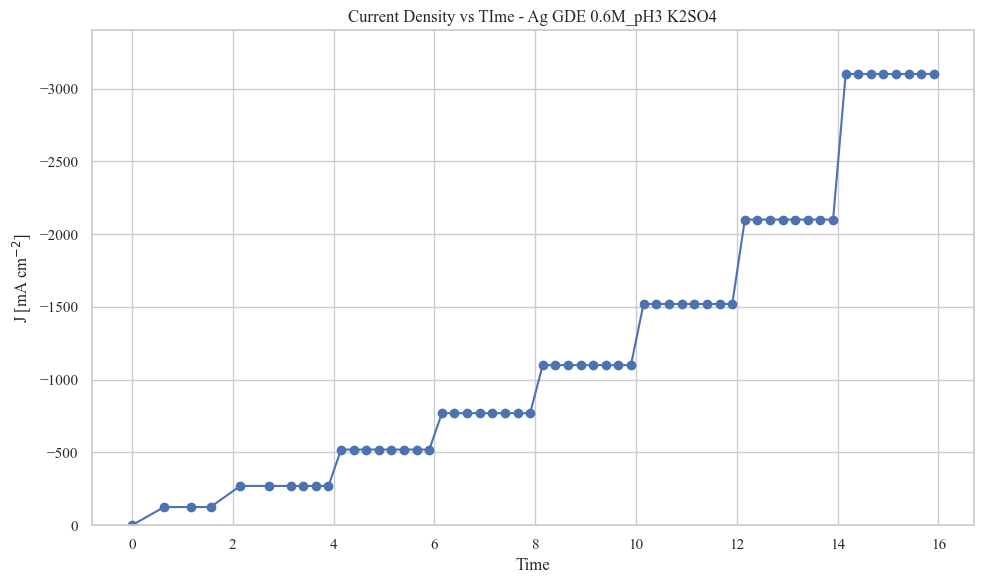

In [771]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.6M_pH3 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

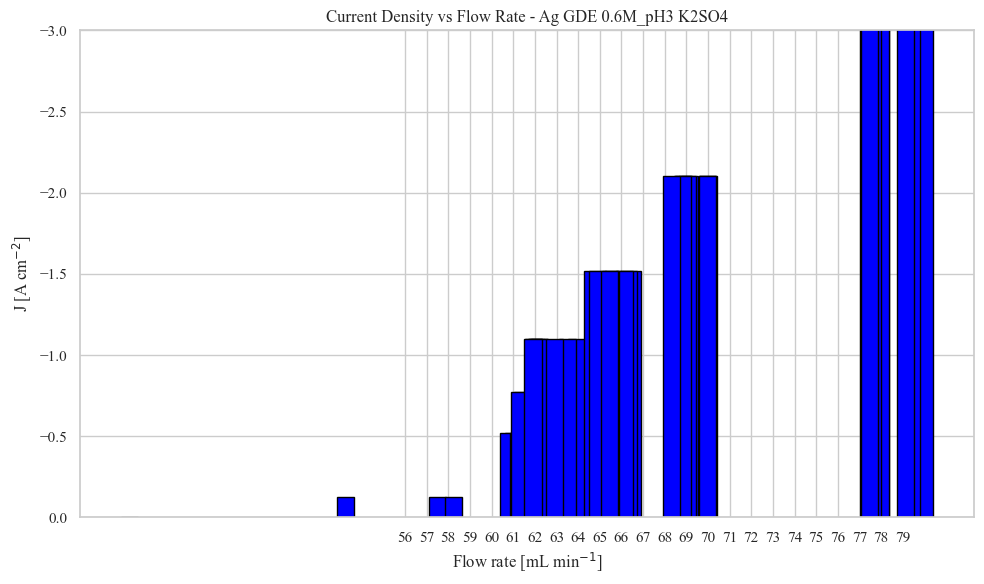

In [772]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.6M_pH3 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


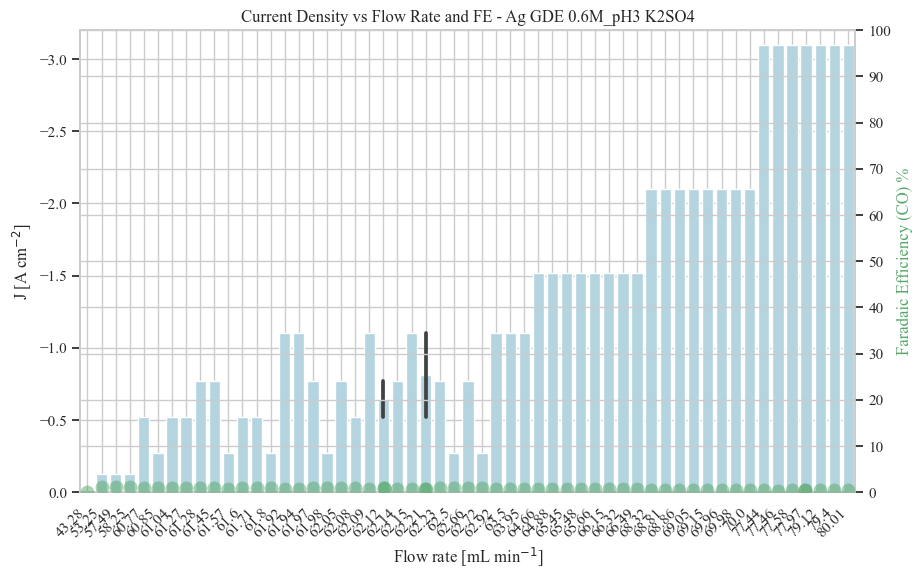

In [773]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.6M_pH3 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240610_Ag_GDE_0_6M_pH3_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [774]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [775]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240610 - Ag60 GDE_0.6M K2SO4_pH3

17-Aug-26  12:00 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:44 PM    <DIR>          .ipynb_checkpoints
30-Jul-26  11:09 AM            73,203 0p6M_pH3 K2SO4_20240611_0641_1min - Copy.xlsx
30-Jul-26  11:10 AM            47,648 0p6M_pH3 K2SO4_20240611_0641_1min.xlsx
11-Jun-24  08:42 AM            10,763 0p6M_pH3 K2SO4_20240611_0641_5min.xlsx
11-Jun-24  08:42 AM           236,076 0p6M_pH3 K2SO4_20240611_0641_Line_1.csv
12-May-25  02:01 PM           714,841 20240610 - Ag60 GDE_0.6 M K2SO4_pH3.ipynb
17-Aug-26  12:00 AM           818,439 20240610 - Ag60 GDE_0.6 M K2SO4_pH3-CORRECTED.ipynb
17-Aug-26  12:07 AM               584 20240610_0.6 M K2SO4_pH3_Energy Consumption.csv
16-Aug-26  10:48 PM             5,830 20240610_0.6M K2SO4_pH3.csv
17-Aug-26  12:07 AM             1,399 202

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


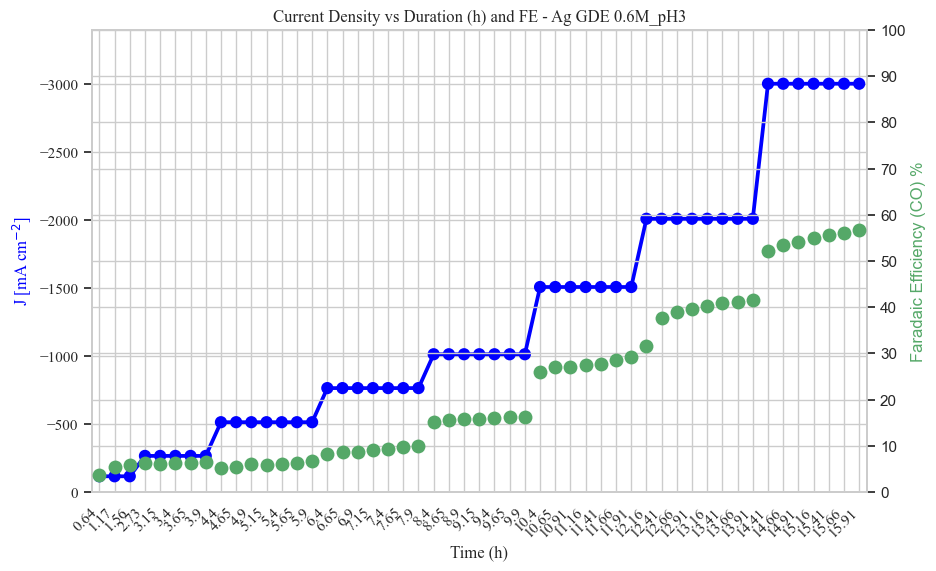

In [776]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.6M_pH3')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(H2)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240610_Ag_GDE_0_6M_pH3_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from first step in each current

In [777]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.16].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,53.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.116,2024-06-10 16:11:35,0.64,0.076311,...,53.25,0.0,-116.0,0.125,0.116,45.914814,41.988366,50.070845,45.981882,104.149861
2,Ag60 GDE in PTFE holder,60,57.49,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.116,2024-06-10 16:43:37,1.17,0.110051,...,57.49,1.0,-116.0,0.125,0.116,45.914814,41.988366,50.070845,45.981882,99.576479
3,Ag60 GDE in PTFE holder,60,58.25,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.116,2024-06-10 17:07:07,1.56,0.119555,...,58.25,1.0,-116.0,0.125,0.116,45.914814,41.988366,50.070845,45.981882,96.995808
5,Ag60 GDE in PTFE holder,60,61.98,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 18:17:10,2.73,0.243144,...,61.98,2.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,93.048591
6,Ag60 GDE in PTFE holder,60,62.72,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 18:42:10,3.15,0.232823,...,62.72,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,93.093077
7,Ag60 GDE in PTFE holder,60,61.80,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 18:57:09,3.40,0.236201,...,61.80,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,92.804069
8,Ag60 GDE in PTFE holder,60,60.85,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 19:12:10,3.65,0.240052,...,60.85,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,92.907158
9,Ag60 GDE in PTFE holder,60,62.50,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.266,2024-06-10 19:27:11,3.90,0.244044,...,62.50,3.0,-266.0,0.270,0.266,55.875333,47.752084,60.256741,56.680052,92.694465
10,Ag60 GDE in PTFE holder,60,62.08,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.514,2024-06-10 21:27:15,5.90,0.464905,...,62.08,5.0,-514.0,0.520,0.514,59.813281,58.371875,61.48084,59.872504,93.178897
11,Ag60 GDE in PTFE holder,60,61.71,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.514,2024-06-10 21:12:14,5.65,0.429336,...,61.71,5.0,-514.0,0.520,0.514,59.813281,58.371875,61.48084,59.872504,92.872397


## Current Density vs FE(CO)_ mean and std

### Stacked bar plot

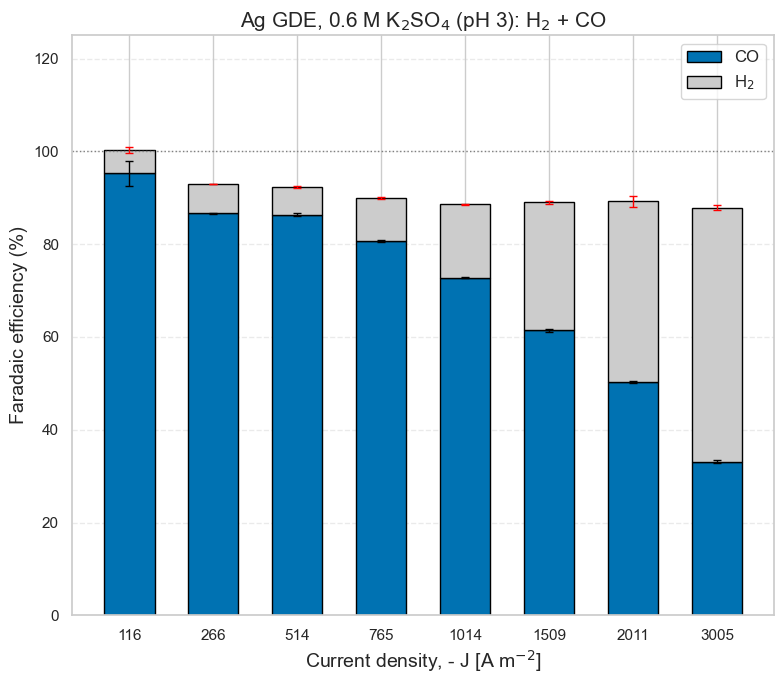

In [778]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

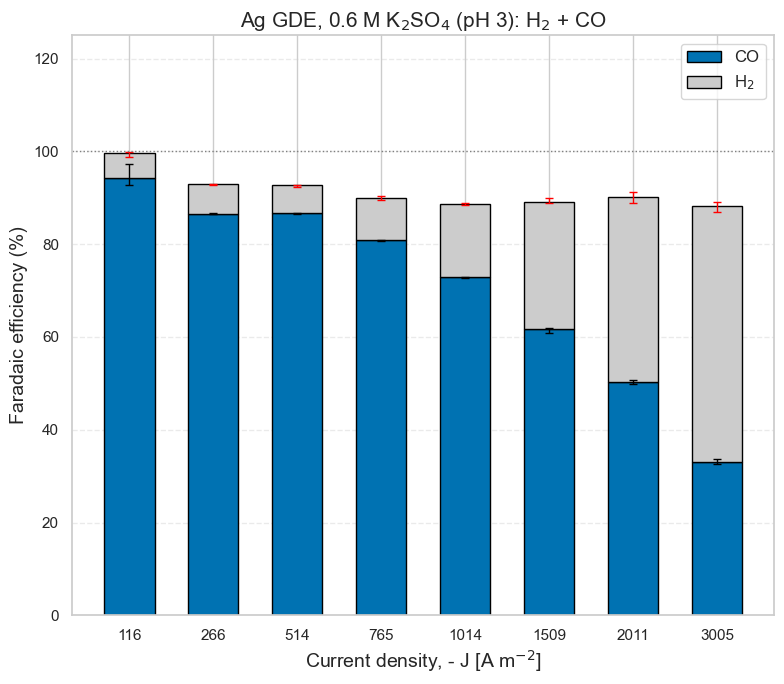

In [779]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [780]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [781]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,4.941186,95.299530,5.328575,94.247904,0.636412,2.722673,1.102298,4.715808,4.513031,...,0.001020,3,0.815544,0.234460,1.524795,3.102235,1.290335,2.286691,0–2,116
1,250,6.283038,86.626434,6.306209,86.600949,0.053938,0.111665,0.120610,0.249691,6.210302,...,0.002245,5,0.095906,0.058621,0.007183,0.082811,0.103089,0.141433,2–4,266
2,500,5.935362,86.324607,6.062558,86.659515,0.196613,0.297471,0.520190,0.787034,5.668644,...,0.003948,7,0.393913,0.082463,0.220414,0.049875,0.591268,0.030537,4–6,514
3,750,9.106897,80.754428,9.112651,80.883347,0.228719,0.191987,0.605135,0.507949,8.690870,...,0.008782,7,0.421781,0.434191,0.269245,0.065065,0.415234,0.088619,6–8,765
4,1000,15.828310,72.767804,15.873841,72.857071,0.153154,0.138016,0.405206,0.365155,15.643735,...,0.020164,7,0.230106,0.219597,0.090400,0.122770,0.335699,0.104842,8–10,1014
5,1500,27.554674,61.433735,27.463043,61.725862,0.403113,0.277149,1.066536,0.733266,27.062906,...,0.051353,7,0.400137,0.671992,0.896278,0.227161,0.291674,0.622109,10–12,1509
6,2000,38.954803,50.282561,39.870395,50.286544,1.133825,0.209534,3.206942,0.592652,38.585562,...,0.095304,8,1.284833,1.055998,0.393270,0.440880,0.884649,0.324368,12–14,2011
7,3000,54.753858,33.087257,54.991719,33.152896,0.589992,0.324181,1.560973,0.857701,53.880272,...,0.186712,7,1.111447,0.853833,0.559853,0.637942,0.473505,0.168537,14–16,3005


In [783]:
Res_Book
# Res_Book.to_csv('20240610_0.6M K2SO4_pH3.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,4.941186,95.299530,5.328575,94.247904,0.636412,2.722673,1.102298,4.715808,4.513031,...,0.001020,3,0.815544,0.234460,1.524795,3.102235,1.290335,2.286691,0–2,116
1,250,6.283038,86.626434,6.306209,86.600949,0.053938,0.111665,0.120610,0.249691,6.210302,...,0.002245,5,0.095906,0.058621,0.007183,0.082811,0.103089,0.141433,2–4,266
2,500,5.935362,86.324607,6.062558,86.659515,0.196613,0.297471,0.520190,0.787034,5.668644,...,0.003948,7,0.393913,0.082463,0.220414,0.049875,0.591268,0.030537,4–6,514
3,750,9.106897,80.754428,9.112651,80.883347,0.228719,0.191987,0.605135,0.507949,8.690870,...,0.008782,7,0.421781,0.434191,0.269245,0.065065,0.415234,0.088619,6–8,765
4,1000,15.828310,72.767804,15.873841,72.857071,0.153154,0.138016,0.405206,0.365155,15.643735,...,0.020164,7,0.230106,0.219597,0.090400,0.122770,0.335699,0.104842,8–10,1014
5,1500,27.554674,61.433735,27.463043,61.725862,0.403113,0.277149,1.066536,0.733266,27.062906,...,0.051353,7,0.400137,0.671992,0.896278,0.227161,0.291674,0.622109,10–12,1509
6,2000,38.954803,50.282561,39.870395,50.286544,1.133825,0.209534,3.206942,0.592652,38.585562,...,0.095304,8,1.284833,1.055998,0.393270,0.440880,0.884649,0.324368,12–14,2011
7,3000,54.753858,33.087257,54.991719,33.152896,0.589992,0.324181,1.560973,0.857701,53.880272,...,0.186712,7,1.111447,0.853833,0.559853,0.637942,0.473505,0.168537,14–16,3005


## Mean and StD of FE(CO) through time

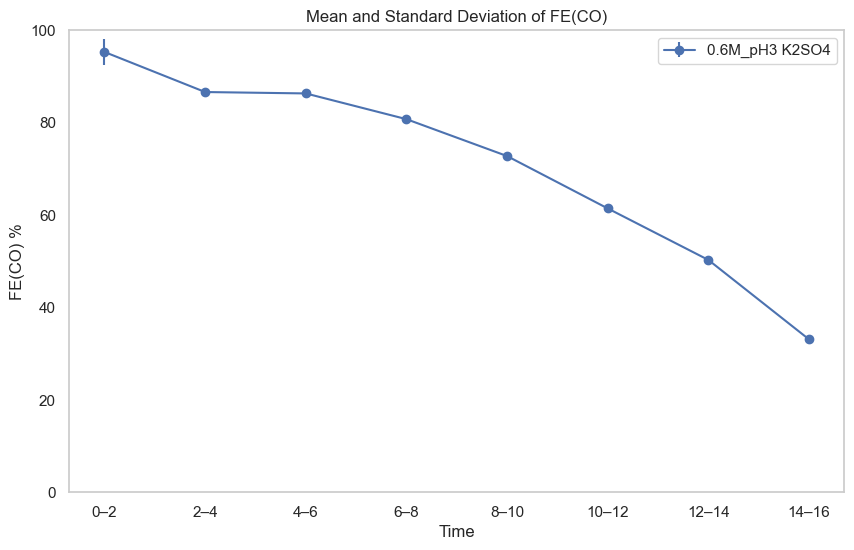

In [784]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.6M_pH3 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240610_0.6M_pH3_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

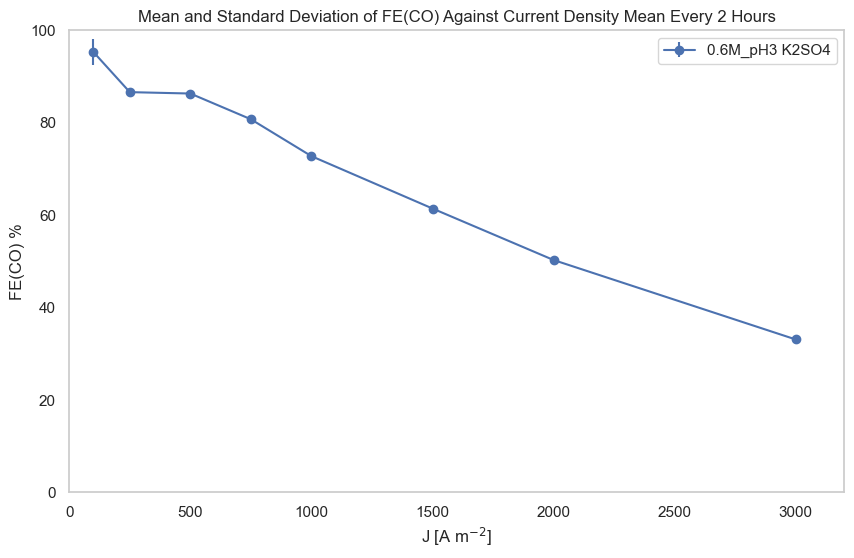

In [785]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.6M_pH3 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240610_0.6M_pH3_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()